# LAB 03: POINT PROCESSING
CÁC PHÉP BIẾN ĐỔI ĐIỂM TRÊN ẢNH SỐ


In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request


urllib.request.urlretrieve("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg", "image.jpg")

urllib.request.urlretrieve("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/aero1.jpg", "image_sang1.jpg")
urllib.request.urlretrieve("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/aero3.jpg", "image_sang2.jpg")
urllib.request.urlretrieve("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/basketball2.png", "image_thieusang.jpg")

print("OpenCV:", cv2.__version__)
print("NumPy :", np.__version__)

img_color = cv2.imread("image.jpg")

img = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("Không đọc được ảnh")

print("shape:", img.shape)
print("dtype:", img.dtype)
print("min/max:", img.min(), img.max())


OpenCV: 4.14.0
NumPy : 2.1.3
shape: (512, 512)
dtype: uint8
min/max: 18 248


## Phần A - Chuẩn hoá và kiểm soát kiểu dữ liệu
### Bài 1. Chuẩn hoá cường độ và chuyển kiểu dữ liệu

Original - dtype: uint8 min/max: 18 248 shape: (512, 512)
Normalized - dtype: float32 min/max: 0.0 1.0 shape: (512, 512)
Restored - dtype: uint8 min/max: 0 255 shape: (512, 512)


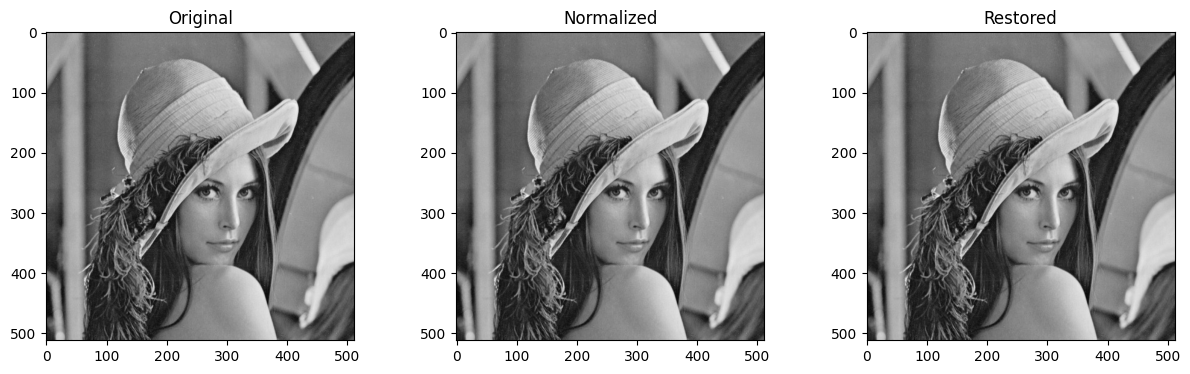

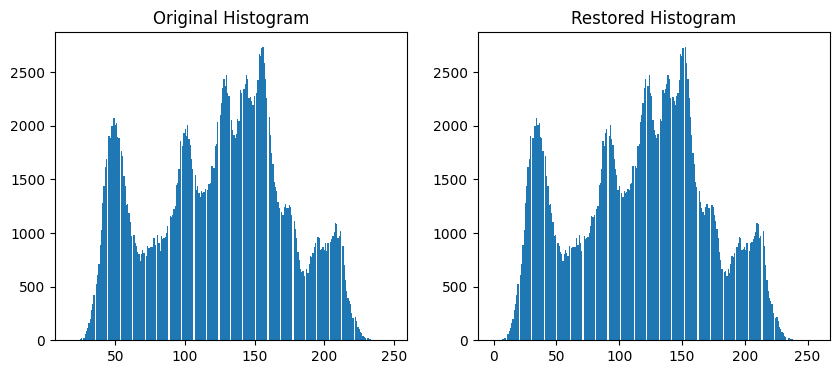

In [12]:
def normalize_to_float01(gray):
    x = gray.astype(np.float32)
    min_val = np.min(x)
    max_val = np.max(x)
    if min_val == max_val:
        return np.zeros_like(x)
    normalized = (x - min_val) / (max_val - min_val)
    return normalized

def float01_to_uint8(image_float):
    scaled = image_float * 255.0
    clipped = np.clip(scaled, 0, 255)
    out = clipped.astype(np.uint8)
    return out

norm = normalize_to_float01(img)
restored = float01_to_uint8(norm)

print("Original - dtype:", img.dtype, "min/max:", img.min(), img.max(), "shape:", img.shape)
print("Normalized - dtype:", norm.dtype, "min/max:", norm.min(), norm.max(), "shape:", norm.shape)
print("Restored - dtype:", restored.dtype, "min/max:", restored.min(), restored.max(), "shape:", restored.shape)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1), plt.imshow(img, cmap="gray"), plt.title("Original")
plt.subplot(1, 3, 2), plt.imshow(norm, cmap="gray"), plt.title("Normalized")
plt.subplot(1, 3, 3), plt.imshow(restored, cmap="gray"), plt.title("Restored")
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.hist(img.ravel(), bins=256), plt.title("Original Histogram")
plt.subplot(1, 2, 2), plt.hist(restored.ravel(), bins=256), plt.title("Restored Histogram")
plt.show()

**Trả lời nhận xét Bài 1:**
- Vì sao nên chuyển sang float32: Để tránh tràn số và giữ độ chính xác phần thập phân khi thực hiện phép chia và phép toán phi tuyến.
- Vì sao cần clip: Tính toán float có thể gây sai số làm vượt quá ngưỡng [0, 255], cần clip để ép kiểu uint8 không bị quấn vòng (modulo).
- Min-max khác chia 255: Min-max kéo giãn khoảng cường độ thực tế ra toàn dải [0, 1], còn chia 255 chỉ thay đổi thang đo.
- Nếu ảnh 12-bit/16-bit: Cần chuẩn hóa theo giá trị max tương ứng (4095 hoặc 65535).


#Mở rộng

Original - dtype: uint8 shape: (512, 512, 3)
  Kênh R: min=27, max=222
  Kênh G: min=0, max=246
  Kênh B: min=49, max=255
Normalized - dtype: float32 shape: (512, 512, 3)
  Kênh R: min=0.000, max=1.000
  Kênh G: min=0.000, max=1.000
  Kênh B: min=0.000, max=1.000
Restored - dtype: uint8 shape: (512, 512, 3)
  Kênh R: min=0, max=255
  Kênh G: min=0, max=255
  Kênh B: min=0, max=255


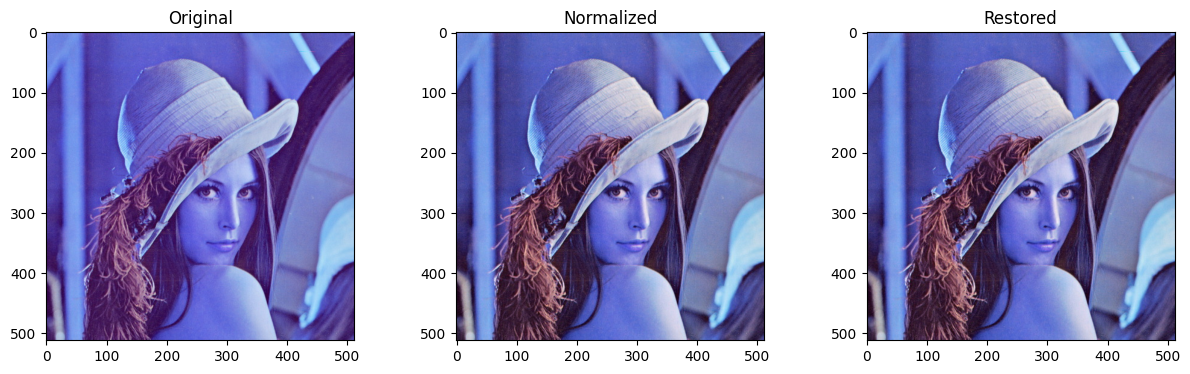

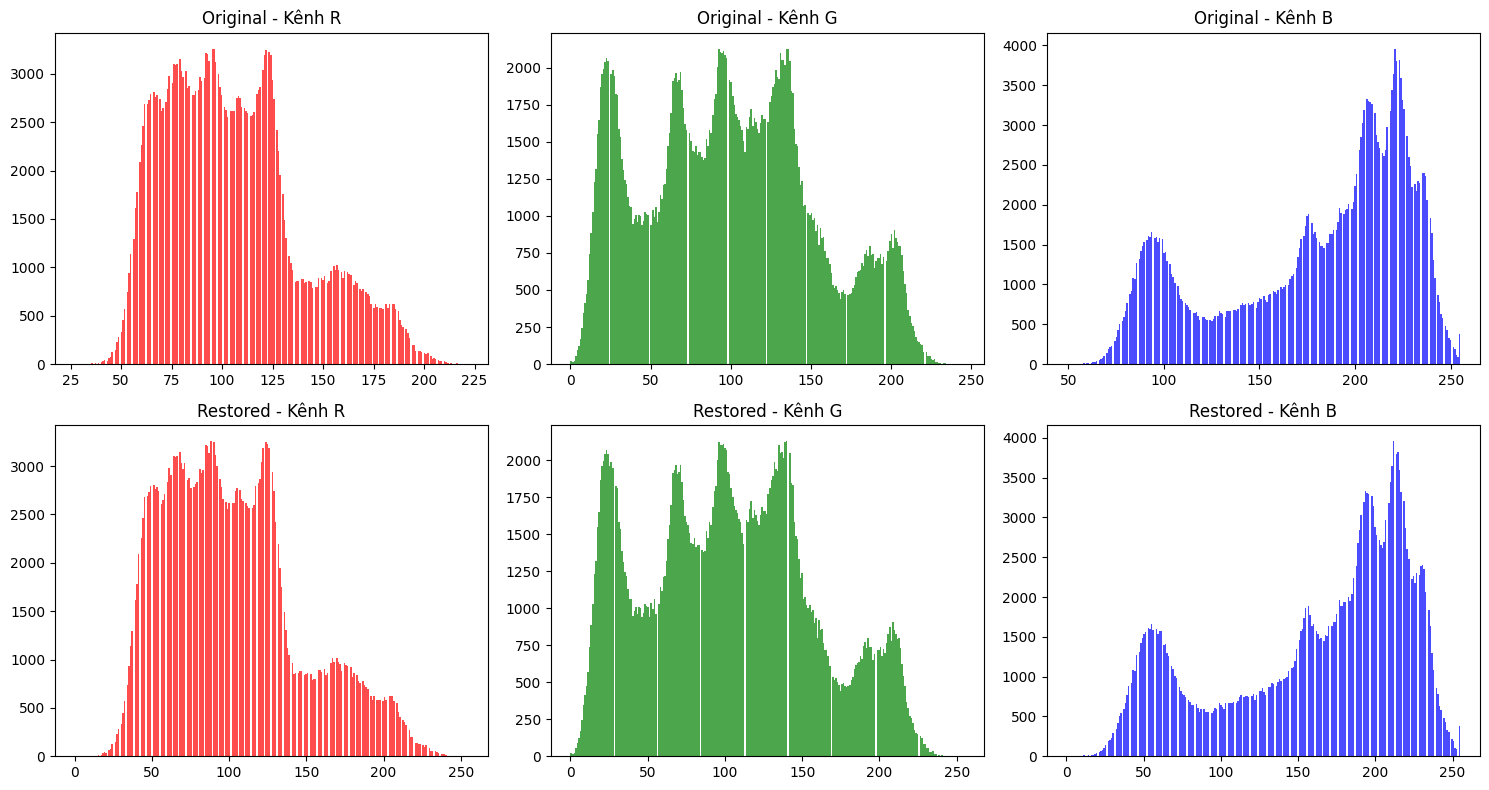

In [13]:
def normalize_color_per_channel(img_color):
    x = img_color.astype(np.float32)
    normalized = np.zeros_like(x)

    num_channels = x.shape[2]
    for c in range(num_channels):
        channel = x[:, :, c]
        min_val = np.min(channel)
        max_val = np.max(channel)
        if min_val == max_val:
            normalized[:, :, c] = np.zeros_like(channel)
        else:
            normalized[:, :, c] = (channel - min_val) / (max_val - min_val)

    return normalized

def float01_to_uint8_color(image_float):
    scaled = image_float * 255.0
    clipped = np.clip(scaled, 0, 255)
    out = clipped.astype(np.uint8)
    return out

norm_color = normalize_color_per_channel(img_color)
restored_color = float01_to_uint8_color(norm_color)

print("Original - dtype:", img_color.dtype, "shape:", img_color.shape)
for c, name in enumerate(["R", "G", "B"]):
    print(f"  Kênh {name}: min={img_color[:,:,c].min()}, max={img_color[:,:,c].max()}")

print("Normalized - dtype:", norm_color.dtype, "shape:", norm_color.shape)
for c, name in enumerate(["R", "G", "B"]):
    print(f"  Kênh {name}: min={norm_color[:,:,c].min():.3f}, max={norm_color[:,:,c].max():.3f}")

print("Restored - dtype:", restored_color.dtype, "shape:", restored_color.shape)
for c, name in enumerate(["R", "G", "B"]):
    print(f"  Kênh {name}: min={restored_color[:,:,c].min()}, max={restored_color[:,:,c].max()}")

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1), plt.imshow(img_color), plt.title("Original")
plt.subplot(1, 3, 2), plt.imshow(norm_color), plt.title("Normalized")
plt.subplot(1, 3, 3), plt.imshow(restored_color), plt.title("Restored")
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = ["red", "green", "blue"]
for c, (name, color) in enumerate(zip(["R", "G", "B"], colors)):
    axes[0, c].hist(img_color[:, :, c].ravel(), bins=256, color=color, alpha=0.7)
    axes[0, c].set_title(f"Original - Kênh {name}")

    axes[1, c].hist(restored_color[:, :, c].ravel(), bins=256, color=color, alpha=0.7)
    axes[1, c].set_title(f"Restored - Kênh {name}")
plt.tight_layout()
plt.show()

## Phần B - Các phép biến đổi điểm
### Bài 2. Ảnh âm bản (Negative)

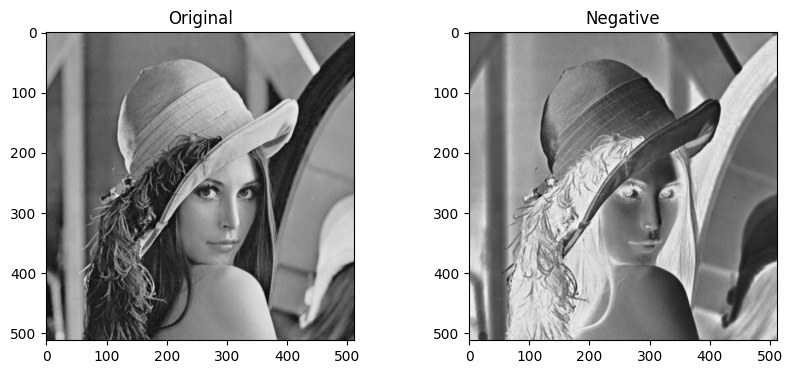

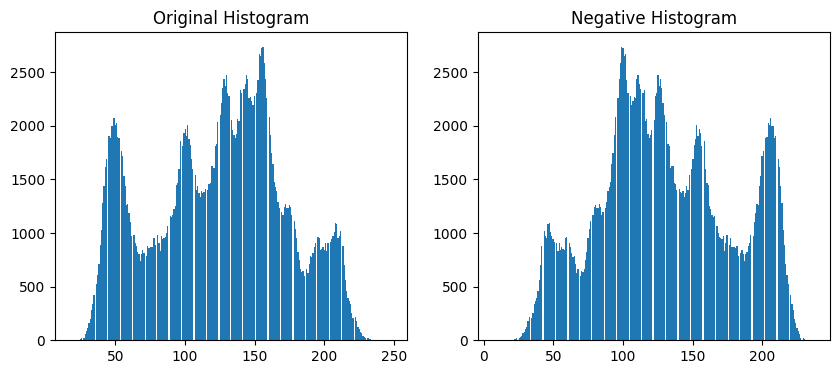

Mean Original: 124.20059967041016
Mean Negative: 130.79940032958984


In [14]:
def negative(gray):
    return 255 - gray

neg = negative(img)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original')
plt.subplot(1, 2, 2), plt.imshow(neg, cmap='gray'), plt.title('Negative')
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.hist(img.ravel(), bins=256), plt.title('Original Histogram')
plt.subplot(1, 2, 2), plt.hist(neg.ravel(), bins=256), plt.title('Negative Histogram')
plt.show()

print('Mean Original:', np.mean(img))
print('Mean Negative:', np.mean(neg))


**Trả lời nhận xét Bài 2:**
- Giải thích: Phép toán s = 255 - r lấy phần bù, nên cường độ tối thành sáng và ngược lại.
- Histogram: Histogram âm bản là bản lật ngược đối xứng qua trục dọc ở giữa (127.5) của ảnh gốc.


#Áp dụng 2 ảnh có độ sáng khác nhau

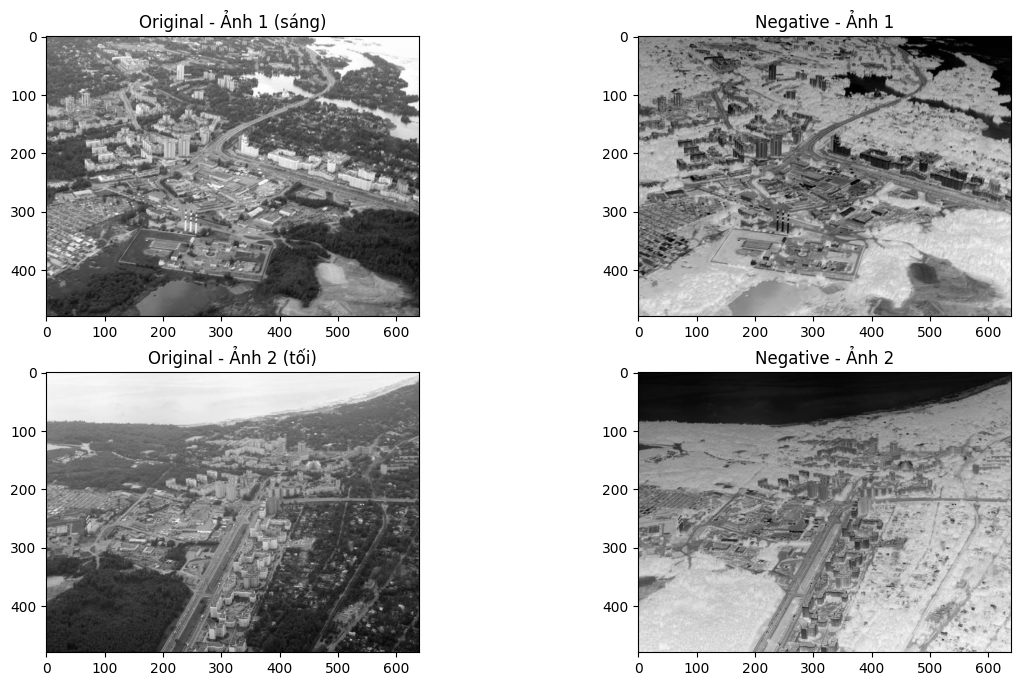

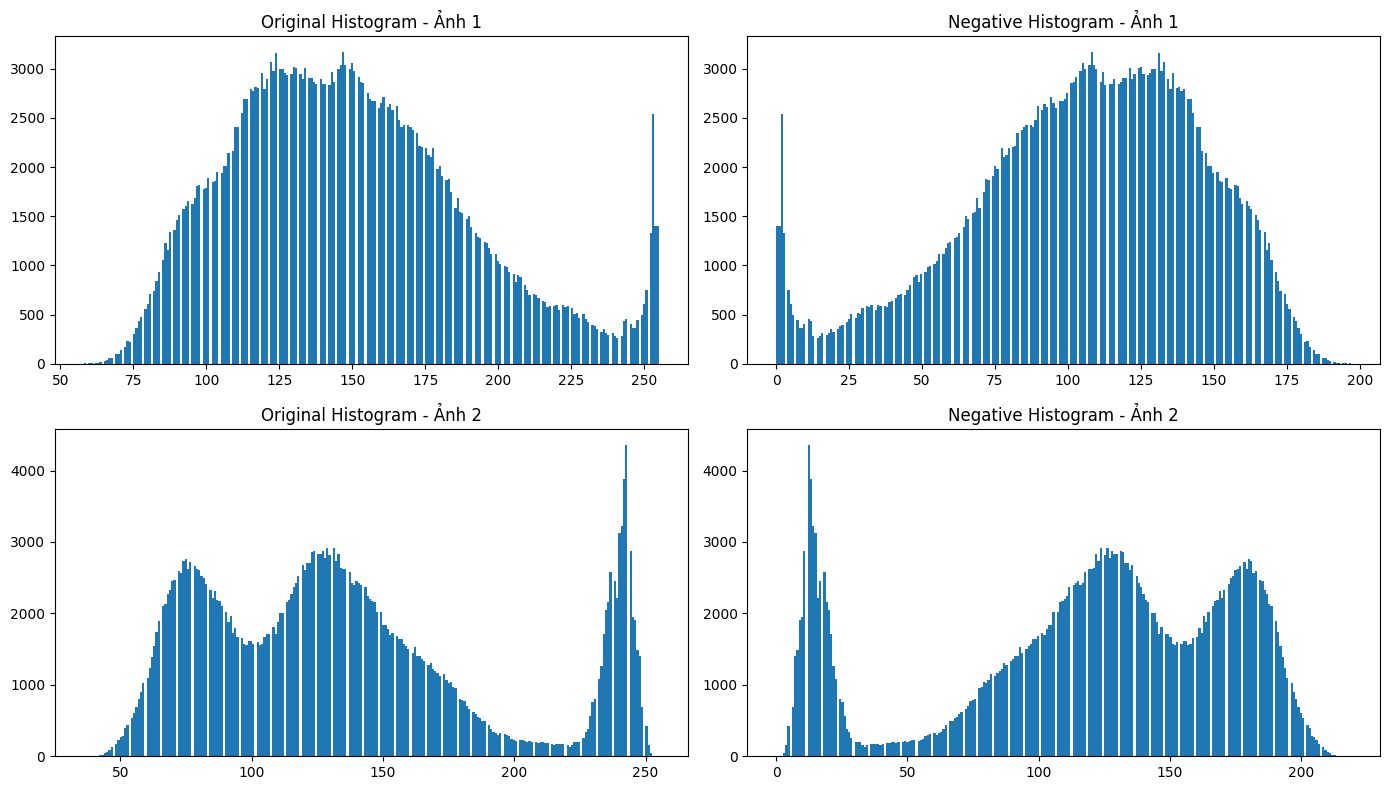

Ảnh 1
Mean Original: 149.92752604166665
Mean Negative: 105.07247395833333
Tổng (Original + Negative): 255.0
Ảnh 2
Mean Original: 136.10515299479167
Mean Negative: 118.89484700520833
Tổng (Original + Negative): 255.0


In [15]:
img_sang1 = cv2.imread("image_sang1.jpg", cv2.IMREAD_GRAYSCALE)
img_sang2 = cv2.imread("image_sang2.jpg", cv2.IMREAD_GRAYSCALE)
def negative(gray):
    return 255 - gray

neg_sang1 = negative(img_sang1)
neg_sang2 = negative(img_sang2)

plt.figure(figsize=(14, 8))
plt.subplot(2, 2, 1), plt.imshow(img_sang1, cmap="gray"), plt.title("Original - Ảnh 1 (sáng)")
plt.subplot(2, 2, 2), plt.imshow(neg_sang1, cmap="gray"), plt.title("Negative - Ảnh 1")
plt.subplot(2, 2, 3), plt.imshow(img_sang2, cmap="gray"), plt.title("Original - Ảnh 2 (tối)")
plt.subplot(2, 2, 4), plt.imshow(neg_sang2, cmap="gray"), plt.title("Negative - Ảnh 2")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].hist(img_sang1.ravel(), bins=256), axes[0, 0].set_title("Original Histogram - Ảnh 1")
axes[0, 1].hist(neg_sang1.ravel(), bins=256), axes[0, 1].set_title("Negative Histogram - Ảnh 1")
axes[1, 0].hist(img_sang2.ravel(), bins=256), axes[1, 0].set_title("Original Histogram - Ảnh 2")
axes[1, 1].hist(neg_sang2.ravel(), bins=256), axes[1, 1].set_title("Negative Histogram - Ảnh 2")
plt.tight_layout()
plt.show()

print("Ảnh 1")
print("Mean Original:", np.mean(img_sang1))
print("Mean Negative:", np.mean(neg_sang1))
print("Tổng (Original + Negative):", np.mean(img_sang1) + np.mean(neg_sang1))

print("Ảnh 2")
print("Mean Original:", np.mean(img_sang2))
print("Mean Negative:", np.mean(neg_sang2))
print("Tổng (Original + Negative):", np.mean(img_sang2) + np.mean(neg_sang2))

### Bài 3. Biến đổi logarit

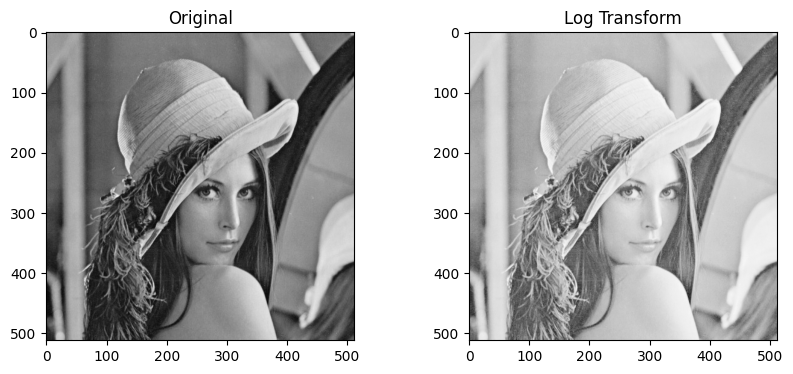

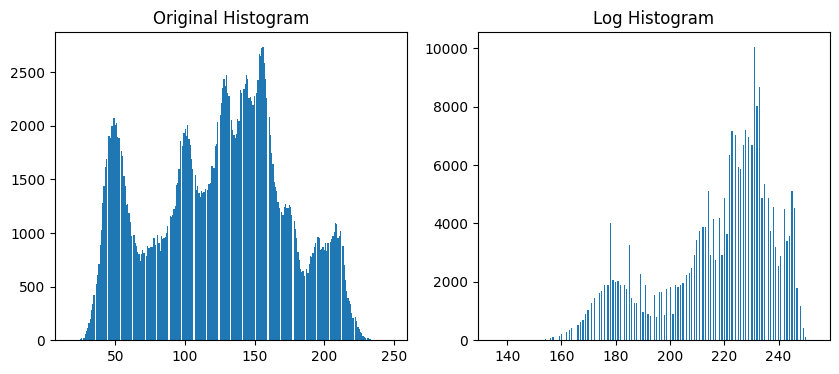

Trước
Mean: 124.20059967041016 Std: 47.90295196809465
Sau
Mean: 217.42181777954102 Std: 20.931048560725266


In [19]:
def log_transform(gray):
    r = gray.astype(np.float32)
    c = 255 / np.log(256)
    s = c * np.log1p(r)
    out = np.clip(s, 0, 255).astype(np.uint8)
    return out

log_img = log_transform(img)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img, cmap="gray"), plt.title("Original")
plt.subplot(1, 2, 2), plt.imshow(log_img, cmap="gray"), plt.title("Log Transform")
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.hist(img.ravel(), bins=256), plt.title("Original Histogram")
plt.subplot(1, 2, 2), plt.hist(log_img.ravel(), bins=256), plt.title("Log Histogram")
plt.show()
print("Trước")
print("Mean:", np.mean(img), "Std:", np.std(img))
print("Sau")
print("Mean:", np.mean(log_img), "Std:", np.std(log_img))


**Trả lời nhận xét Bài 3:**
- Làm rõ vùng tối: Hàm logarit tăng dốc mạnh ở dải giá trị nhỏ, giúp giãn rộng các mức cường độ tối.
- Dùng log(1+r) và np.log1p: Để tránh lỗi tính log(0).
- đồng thời np.log1p đảm bảo độ chính xác tính toán cho số nhỏ.


- Liên hệ ứng dụng:
- Ảnh X-quang y tế: xương và mô hấp thụ tia X khác nhau rất nhiều, tạo ra ảnh có vùng cực sáng (xương) và vùng rất tối (mô mềm) cùng tồn tại. Chi tiết ở vùng tối (mô mềm, mạch máu) thường bị "chìm" và khó phân biệt bằng mắt thường.
- Log transform nén vùng sáng, giãn vùng tối: vì hàm log tăng nhanh ở giá trị nhỏ và chậm dần ở giá trị lớn, các chi tiết ở vùng pixel tối (giá trị thấp) được kéo giãn ra một khoảng giá trị rộng hơn, giúp bác sĩ hoặc phần mềm chẩn đoán dễ nhìn thấy các mô mềm, mạch máu nhỏ, hoặc tổn thương mờ nhạt.
- Ứng dụng tương tự: ảnh vệ tinh (satellite imaging), ảnh chụp phổ Fourier (magnitude spectrum thường có dải giá trị cực lớn, dùng log để hiển thị được), ảnh thiên văn (sao rất sáng cạnh vùng nền tối).

# So sánh Log transformation vs Gamma < 1

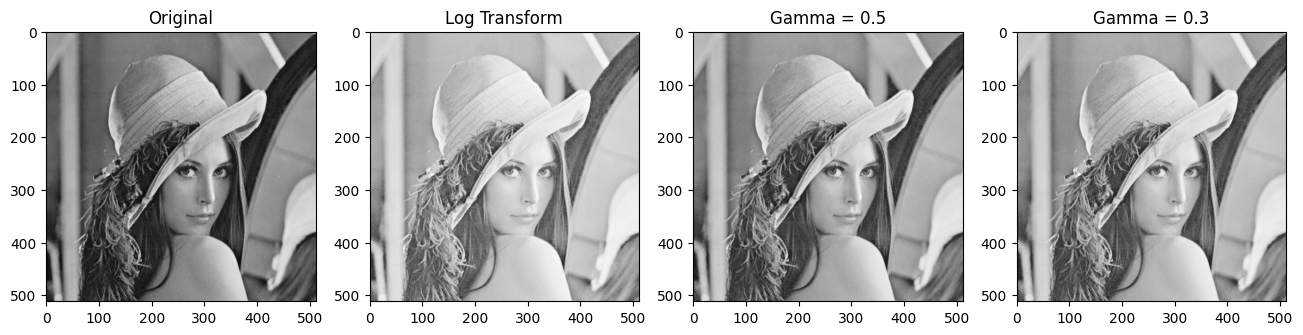

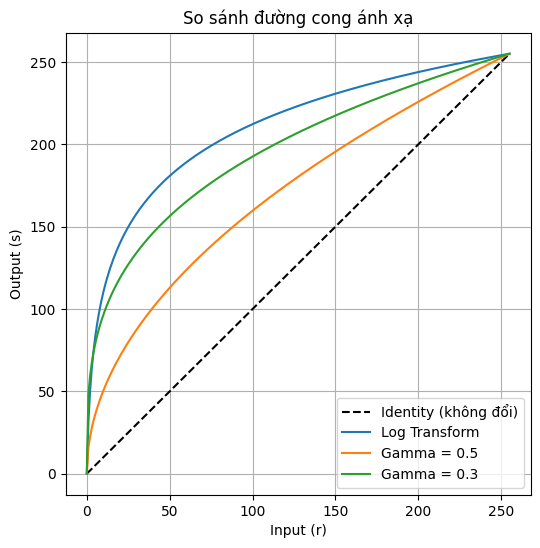

Log      - Mean: 217.42181777954102 Std: 20.931048560725266
Gamma0.5 - Mean: 173.63732528686523 Std: 36.557312291963825
Gamma0.3 - Mean: 201.19824981689453 Std: 26.32173838734404


In [22]:
def gamma_transform(gray, gamma):
    r = gray.astype(np.float32) / 255.0
    s = np.power(r, gamma)
    out = np.clip(s * 255.0, 0, 255).astype(np.uint8)
    return out

log_img = log_transform(img)
gamma_img_05 = gamma_transform(img, 0.5)
gamma_img_03 = gamma_transform(img, 0.3)

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1), plt.imshow(img, cmap="gray"), plt.title("Original")
plt.subplot(1, 4, 2), plt.imshow(log_img, cmap="gray"), plt.title("Log Transform")
plt.subplot(1, 4, 3), plt.imshow(gamma_img_05, cmap="gray"), plt.title("Gamma = 0.5")
plt.subplot(1, 4, 4), plt.imshow(gamma_img_03, cmap="gray"), plt.title("Gamma = 0.3")
plt.show()

#Vẽ đường cong ánh xạ
r_vals = np.arange(0, 256).astype(np.float32)
c = 255 / np.log(256)
log_curve = c * np.log1p(r_vals)
gamma_curve_05 = 255 * np.power(r_vals / 255.0, 0.5)
gamma_curve_03 = 255 * np.power(r_vals / 255.0, 0.3)

plt.figure(figsize=(6, 6))
plt.plot(r_vals, r_vals, "k--", label="Identity (không đổi)")
plt.plot(r_vals, log_curve, label="Log Transform")
plt.plot(r_vals, gamma_curve_05, label="Gamma = 0.5")
plt.plot(r_vals, gamma_curve_03, label="Gamma = 0.3")
plt.xlabel("Input (r)"), plt.ylabel("Output (s)")
plt.legend(), plt.title("So sánh đường cong ánh xạ")
plt.grid(True)
plt.show()

#So sánh thống kê
print("Log      - Mean:", np.mean(log_img), "Std:", np.std(log_img))
print("Gamma0.5 - Mean:", np.mean(gamma_img_05), "Std:", np.std(gamma_img_05))
print("Gamma0.3 - Mean:", np.mean(gamma_img_03), "Std:", np.std(gamma_img_03))

### Bài 4. Biến đổi lũy thừa (Gamma)

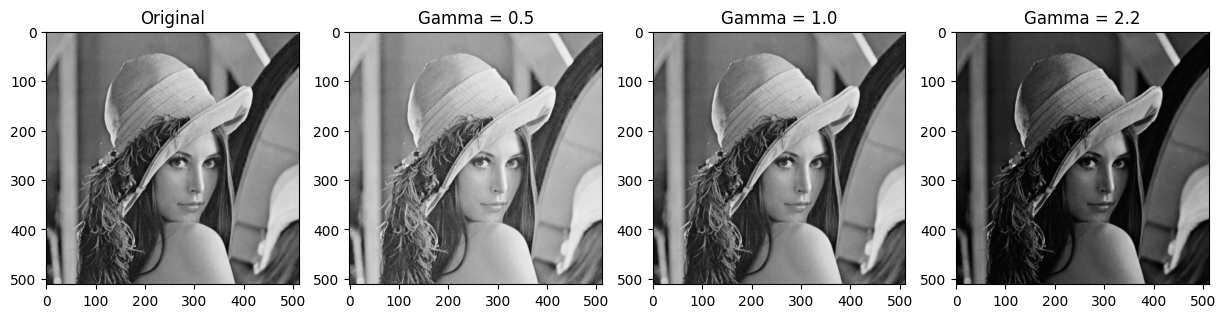

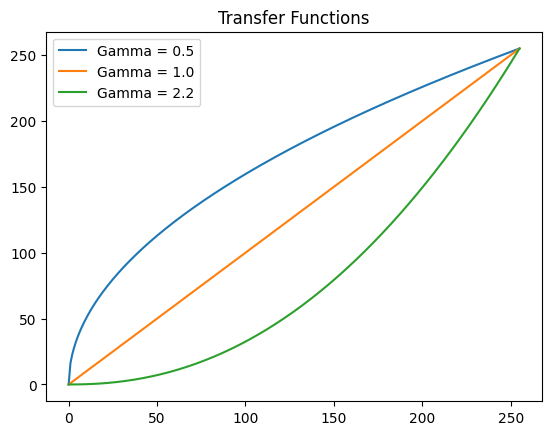

Gamma 0.5 - Mean: 173.64, Std: 36.56
Gamma 1.0 - Mean: 124.20, Std: 47.90
Gamma 2.2 - Mean: 62.09, Std: 45.49


In [23]:
def gamma_transform(gray, gamma):
    r = gray.astype(np.float32) / 255.0
    s = np.power(r, gamma)
    out = np.clip(s * 255.0, 0, 255).astype(np.uint8)
    return out

gammas = [0.5, 1.0, 2.2]
results = {}
for g in gammas:
    results[g] = gamma_transform(img, g)

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1), plt.imshow(img, cmap="gray"), plt.title("Original")
for i, g in enumerate(gammas):
    plt.subplot(1, 4, i+2), plt.imshow(results[g], cmap="gray"), plt.title(f"Gamma = {g}")
plt.show()

x = np.arange(0, 256)
plt.figure()
for g in gammas:
    plt.plot(x, 255 * np.power(x/255.0, g), label=f"Gamma = {g}")
plt.legend(), plt.title("Transfer Functions"), plt.show()

for g in gammas:
    print(f"Gamma {g} - Mean: {np.mean(results[g]):.2f}, Std: {np.std(results[g]):.2f}")

**Trả lời nhận xét Bài 4:**
- Dự đoán Gamma = 0.5 làm ảnh sáng lên, Gamma = 2.2 làm tối đi
- Gamma < 1 kéo giãn vùng tối làm ảnh sáng lên. Gamma > 1 nén vùng tối, kéo giãn vùng sáng làm ảnh tối đi.
- Gamma = 1 là biến đổi đồng nhất (identity), ảnh không đổi.


# Mở rộng - Thử trên ảnh thiếu sáng

Ảnh thiếu sáng - dtype: uint8 shape: (480, 640)
Mean: 119.94321614583333 Std: 61.88585477867827


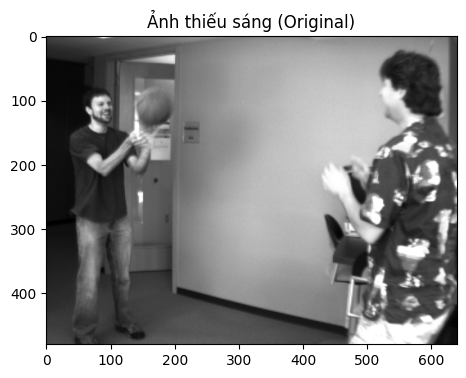

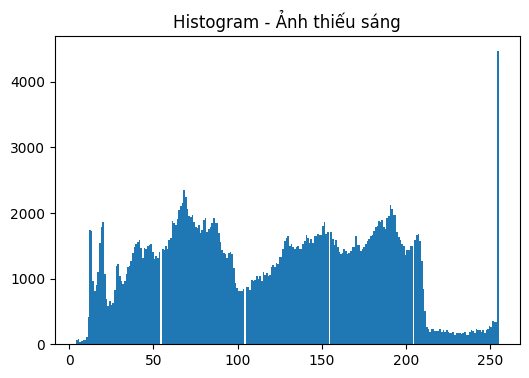

In [27]:
img_thieusang = cv2.imread("image_thieusang.jpg")
img_thieusang = cv2.cvtColor(img_thieusang_bgr, cv2.COLOR_BGR2GRAY)

print("Ảnh thiếu sáng - dtype:", img_thieusang.dtype, "shape:", img_thieusang.shape)
print("Mean:", np.mean(img_thieusang), "Std:", np.std(img_thieusang))

plt.figure(figsize=(6, 4))
plt.imshow(img_thieusang, cmap="gray"), plt.title("Ảnh thiếu sáng (Original)")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(img_thieusang.ravel(), bins=256), plt.title("Histogram - Ảnh thiếu sáng")
plt.show()

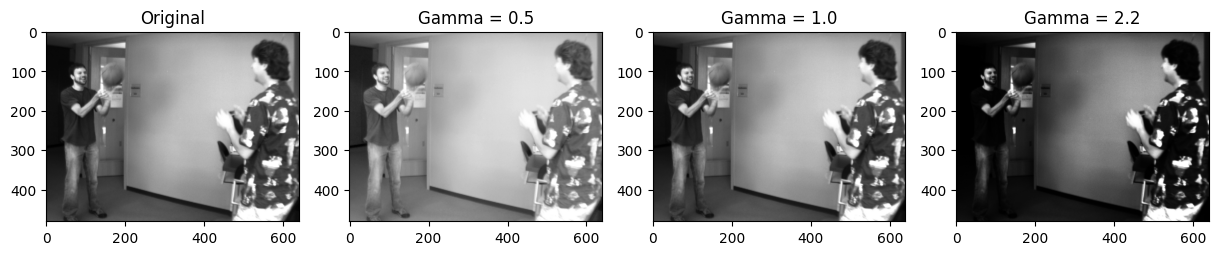

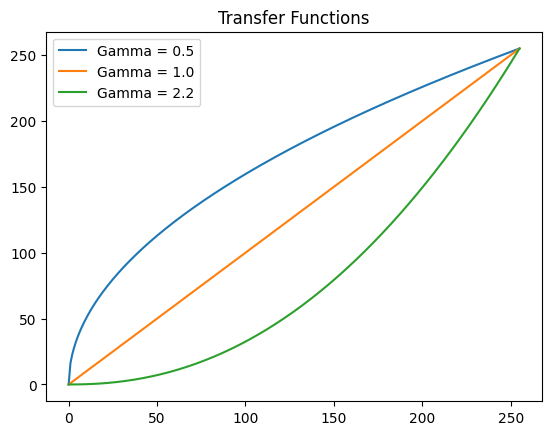

Gamma 0.5 - Mean: 167.30, Std: 49.19
Gamma 1.0 - Mean: 119.94, Std: 61.89
Gamma 2.2 - Mean: 64.99, Std: 60.30


In [28]:
def gamma_transform(gray, gamma):
    r = gray.astype(np.float32) / 255.0
    s = np.power(r, gamma)
    out = np.clip(s * 255.0, 0, 255).astype(np.uint8)
    return out

gammas = [0.5, 1.0, 2.2]
results = {}
for g in gammas:
    results[g] = gamma_transform(img_thieusang, g)

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1), plt.imshow(img_thieusang, cmap="gray"), plt.title("Original")
for i, g in enumerate(gammas):
    plt.subplot(1, 4, i+2), plt.imshow(results[g], cmap="gray"), plt.title(f"Gamma = {g}")
plt.show()

x = np.arange(0, 256)
plt.figure()
for g in gammas:
    plt.plot(x, 255 * np.power(x/255.0, g), label=f"Gamma = {g}")
plt.legend(), plt.title("Transfer Functions"), plt.show()

for g in gammas:
    print(f"Gamma {g} - Mean: {np.mean(results[g]):.2f}, Std: {np.std(results[g]):.2f}")

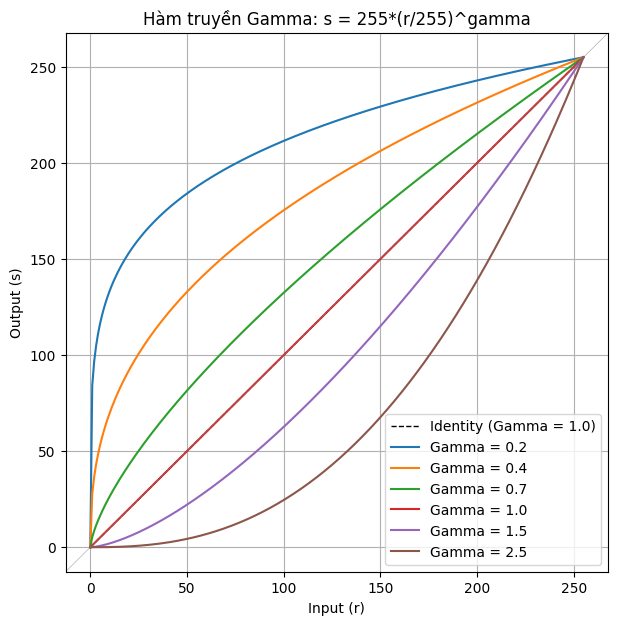

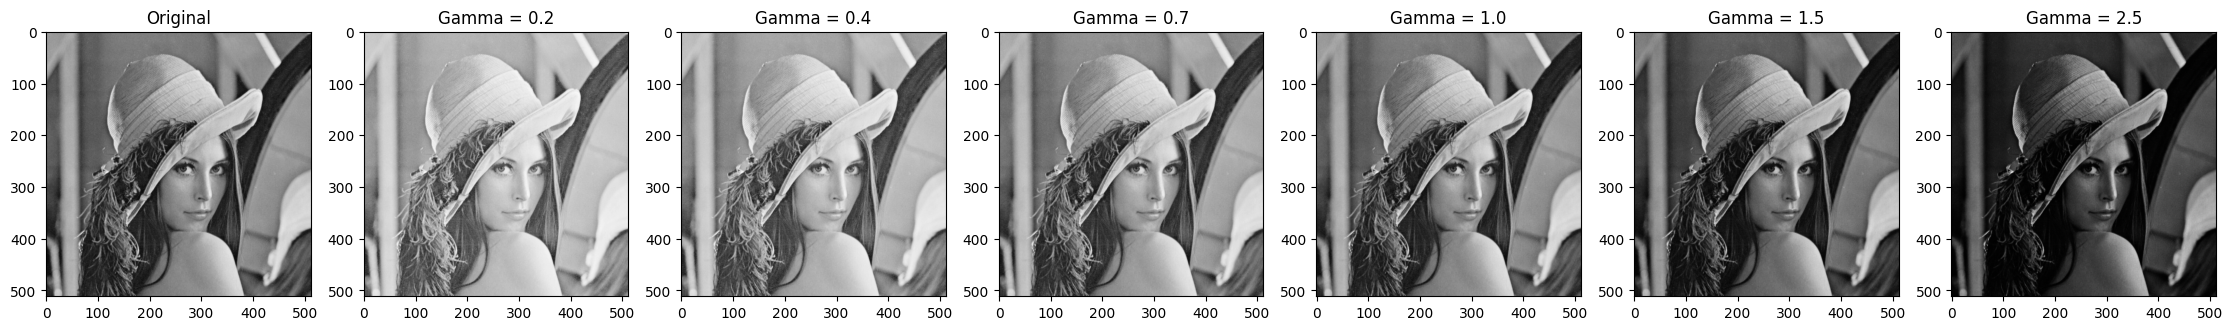

Gamma 0.2  - Mean: 217.18, Std: 19.30
Gamma 0.4  - Mean: 186.75, Std: 32.03
Gamma 0.7  - Mean: 150.95, Std: 42.95
Gamma 1.0  - Mean: 124.20, Std: 47.90
Gamma 1.5  - Mean: 91.16, Std: 49.28
Gamma 2.5  - Mean: 53.36, Std: 43.24


In [31]:
gammas = [0.2, 0.4, 0.7, 1.0, 1.5, 2.5]
results = {}
for g in gammas:
    results[g] = gamma_transform(img, g)

#Vẽ hàm truyền
x = np.arange(0, 256)
plt.figure(figsize=(7, 7))
plt.plot(x, x, "k--", linewidth=1, label="Identity (Gamma = 1.0)")
for g in gammas:
    y = 255 * np.power(x / 255.0, g)
    plt.plot(x, y, label=f"Gamma = {g}")
plt.xlabel("Input (r)")
plt.ylabel("Output (s)")
plt.title("Hàm truyền Gamma: s = 255*(r/255)^gamma")
plt.legend()
plt.grid(True)
plt.axline((0, 0), (255, 255), color="gray", linewidth=0.3)  # đường tham chiếu
plt.show()

#Ảnh đầu ra
n = len(gammas) + 1
plt.figure(figsize=(4 * n, 4))
plt.subplot(1, n, 1), plt.imshow(img, cmap="gray"), plt.title("Original")
for i, g in enumerate(gammas):
    plt.subplot(1, n, i + 2), plt.imshow(results[g], cmap="gray"), plt.title(f"Gamma = {g}")
plt.show()

for g in gammas:
    print(f"Gamma {g:<4} - Mean: {np.mean(results[g]):.2f}, Std: {np.std(results[g]):.2f}")

### Bài 5. Piecewise Linear

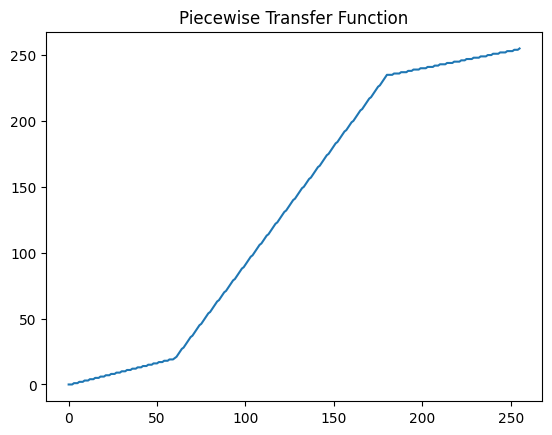

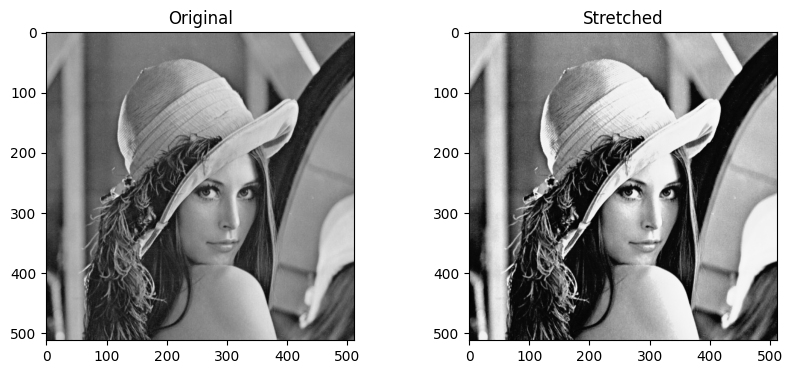

In [33]:
def piecewise_linear(gray, r1, s1, r2, s2):
    r = gray.astype(np.float32)
    s = np.zeros_like(r)
    m1 = r <= r1
    m2 = (r > r1) & (r <= r2)
    m3 = r > r2
    if r1 > 0: s[m1] = (s1 / r1) * r[m1]
    if r2 > r1: s[m2] = ((s2 - s1) / (r2 - r1)) * (r[m2] - r1) + s1
    if r2 < 255: s[m3] = ((255 - s2) / (255 - r2)) * (r[m3] - r2) + s2
    return np.clip(s, 0, 255).astype(np.uint8)

r1, s1, r2, s2 = 60, 20, 180, 235
stretched = piecewise_linear(img, r1, s1, r2, s2)

x = np.arange(0, 256)
y = piecewise_linear(np.array([x]), r1, s1, r2, s2)[0]
plt.plot(x, y), plt.title("Piecewise Transfer Function"), plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img, cmap="gray"), plt.title("Original")
plt.subplot(1, 2, 2), plt.imshow(stretched, cmap="gray"), plt.title("Stretched")
plt.show()


**Trả lời nhận xét Bài 5:**
- Ý nghĩa 2 điểm gãy: Chia dải mức xám thành 3 vùng để kéo giãn hay nén tuyến tính riêng rẽ.
- Nhấn mạnh vùng trung bình: Đặt r1, r2 bao quanh vùng trung bình và s1 thấp, s2 cao để tạo độ dốc lớn đoạn giữa.
- Tính liên tục: Tránh các ranh giới ảo (artifacts) gây đứt gãy màu đột ngột trên ảnh.


#Mở rộng

r1 tự động (percentile 2%): 40.0
r2 tự động (percentile 98%): 212.0
So sánh với giá trị min/max thực tế: min=18, max=248


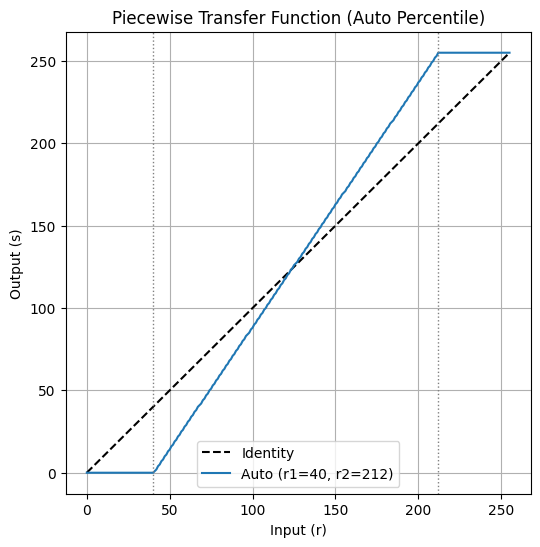

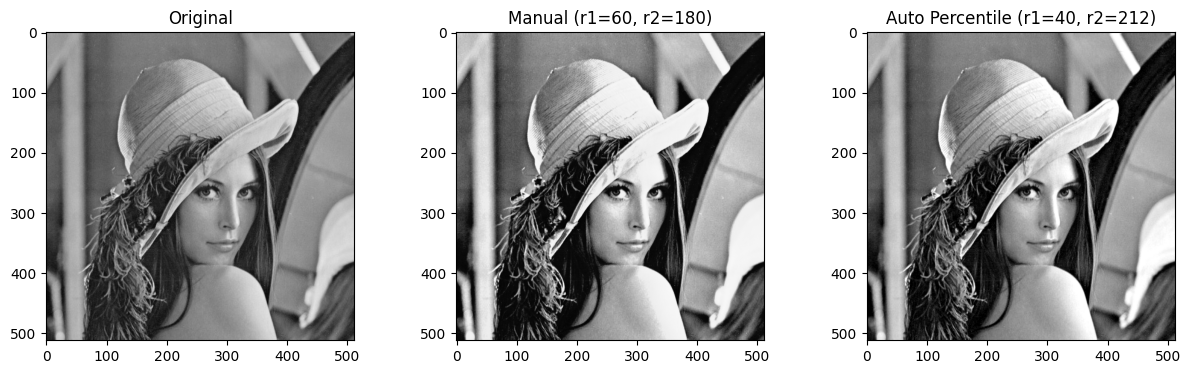

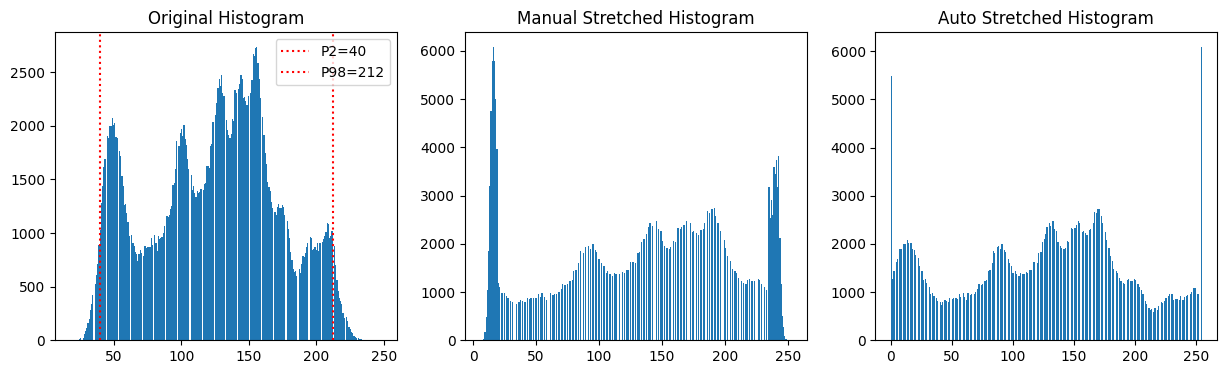

Original     - Mean: 124.20059967041016 Std: 47.90295196809465
Manual       - Mean: 133.22843170166016 Std: 75.40834026837753
Auto Percent - Mean: 124.29769515991211 Std: 70.54563744673602


In [35]:
def piecewise_linear(gray, r1, s1, r2, s2):
    r = gray.astype(np.float32)
    s = np.zeros_like(r)
    m1 = r <= r1
    m2 = (r > r1) & (r <= r2)
    m3 = r > r2
    if r1 > 0: s[m1] = (s1 / r1) * r[m1]
    if r2 > r1: s[m2] = ((s2 - s1) / (r2 - r1)) * (r[m2] - r1) + s1
    if r2 < 255: s[m3] = ((255 - s2) / (255 - r2)) * (r[m3] - r2) + s2
    return np.clip(s, 0, 255).astype(np.uint8)

def auto_contrast_stretch(gray, low_percentile=2, high_percentile=98, s1=0, s2=255):
    r1 = np.percentile(gray, low_percentile)
    r2 = np.percentile(gray, high_percentile)

    if r1 >= r2:
        r1, r2 = np.min(gray), np.max(gray)

    stretched = piecewise_linear(gray, r1, s1, r2, s2)
    return stretched, r1, r2
stretched_auto, r1_auto, r2_auto = auto_contrast_stretch(img, low_percentile=2, high_percentile=98)
print(f"r1 tự động (percentile 2%): {r1_auto:.1f}")
print(f"r2 tự động (percentile 98%): {r2_auto:.1f}")
print(f"So sánh với giá trị min/max thực tế: min={img.min()}, max={img.max()}")
x = np.arange(0, 256)
y_auto = piecewise_linear(np.array([x]), r1_auto, 0, r2_auto, 255)[0]
plt.figure(figsize=(6, 6))
plt.plot(x, x, "k--", label="Identity")
plt.plot(x, y_auto, label=f"Auto (r1={r1_auto:.0f}, r2={r2_auto:.0f})")
plt.axvline(r1_auto, color="gray", linestyle=":", linewidth=1)
plt.axvline(r2_auto, color="gray", linestyle=":", linewidth=1)
plt.legend(), plt.title("Piecewise Transfer Function (Auto Percentile)")
plt.xlabel("Input (r)"), plt.ylabel("Output (s)")
plt.grid(True)
plt.show()

#So sánh ảnh
stretched_manual = piecewise_linear(img, 60, 20, 180, 235)
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1), plt.imshow(img, cmap="gray"), plt.title("Original")
plt.subplot(1, 3, 2), plt.imshow(stretched_manual, cmap="gray"), plt.title("Manual (r1=60, r2=180)")
plt.subplot(1, 3, 3), plt.imshow(stretched_auto, cmap="gray"), plt.title(f"Auto Percentile (r1={r1_auto:.0f}, r2={r2_auto:.0f})")
plt.show()

#So sánh histogram
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1), plt.hist(img.ravel(), bins=256), plt.title("Original Histogram")
plt.axvline(r1_auto, color="red", linestyle=":", label=f"P2={r1_auto:.0f}")
plt.axvline(r2_auto, color="red", linestyle=":", label=f"P98={r2_auto:.0f}")
plt.legend()
plt.subplot(1, 3, 2), plt.hist(stretched_manual.ravel(), bins=256), plt.title("Manual Stretched Histogram")
plt.subplot(1, 3, 3), plt.hist(stretched_auto.ravel(), bins=256), plt.title("Auto Stretched Histogram")
plt.show()
print("Original     - Mean:", np.mean(img), "Std:", np.std(img))
print("Manual       - Mean:", np.mean(stretched_manual), "Std:", np.std(stretched_manual))
print("Auto Percent - Mean:", np.mean(stretched_auto), "Std:", np.std(stretched_auto))

#So sánh tính linh hoạt giữa Piecewise Linear và Gamma Correction

1. Số bậc tự do (degrees of freedom)
- Piecewise có 4 tham số (r1, s1, r2, s2)
- gamma có 1 tham số (y)
- Vậy: Piecewise linh hoạt hơn về mặt toán học: ta có thể chọn bất kỳ điểm gãy nào (r1, r2) và độ dốc bất kỳ ở mỗi đoạn, kể cả làm giảm tương phản ở một vùng và tăng tương phản ở vùng khác trong cùng một ảnh. Gamma chỉ có một dạng cong cố định (lồi hoặc lõm tùy γ >1 hay <1), không thể "vừa nén vừa giãn" đồng thời như piecewise.

## Phần C - Pipeline

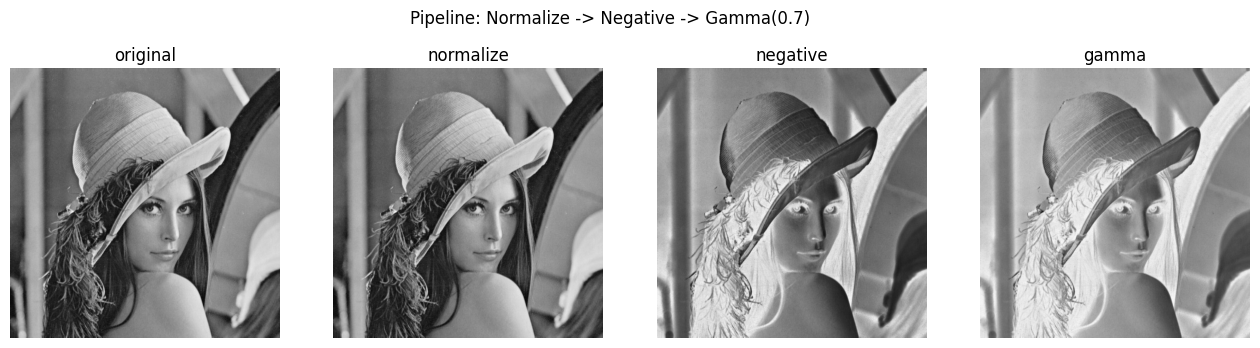

Các stage đã lưu: ['original', 'normalize', 'negative', 'gamma']
Mean kết quả cuối: 162.40405654907227


In [42]:
def point_processing_pipeline(gray, normalize=False, use_negative=False, use_log=False, gamma=None, piecewise_params=None):
    result = gray.copy()
    stages = {'original': result.copy()}
    if normalize:
        result = float01_to_uint8(normalize_to_float01(result))
        stages['normalize'] = result.copy()
    if use_negative:
        result = negative(result)
        stages['negative'] = result.copy()
    if use_log:
        result = log_transform(result)
        stages['log'] = result.copy()
    if gamma is not None:
        result = gamma_transform(result, gamma)
        stages['gamma'] = result.copy()
    if piecewise_params is not None:
        result = piecewise_linear(result, *piecewise_params)
        stages['piecewise'] = result.copy()
    return result, stages


def show_pipeline_stages(stages, title_prefix=""):
    n = len(stages)
    plt.figure(figsize=(4 * n, 4))
    for i, (name, im) in enumerate(stages.items()):
        plt.subplot(1, n, i + 1)
        plt.imshow(im, cmap="gray")
        plt.title(name)
        plt.axis("off")
    plt.suptitle(title_prefix)
    plt.show()

res, stages = point_processing_pipeline(img, normalize=True, use_negative=True, gamma=0.7)
show_pipeline_stages(stages, "Pipeline: Normalize -> Negative -> Gamma(0.7)")

print("Các stage đã lưu:", list(stages.keys()))
print("Mean kết quả cuối:", np.mean(res))

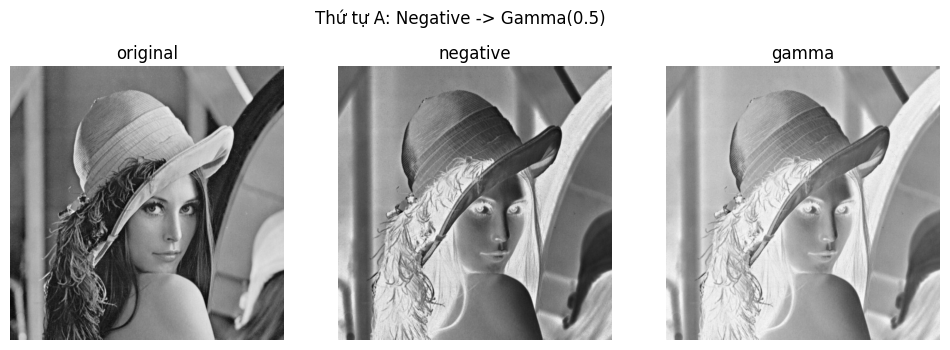

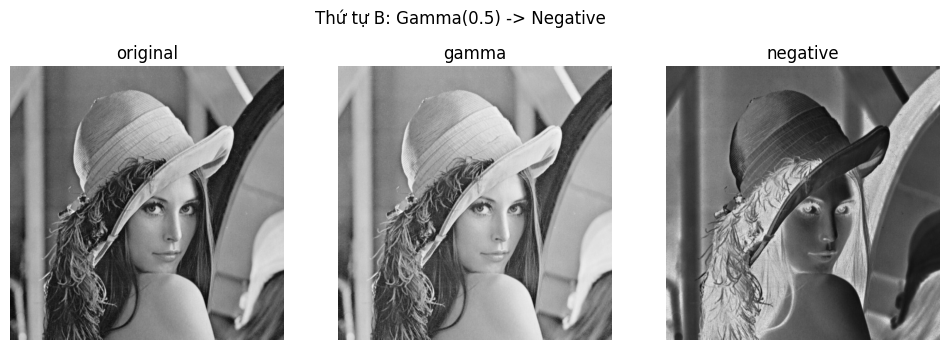

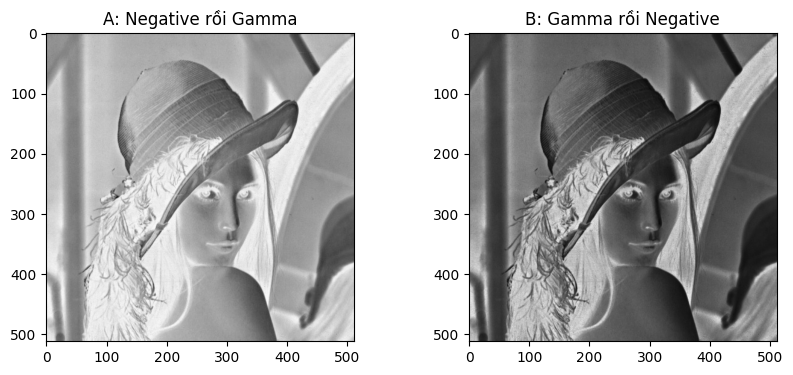

Số pixel khác nhau giữa 2 kết quả: 262144
Mean A: 178.73822021484375  Mean B: 81.36267471313477


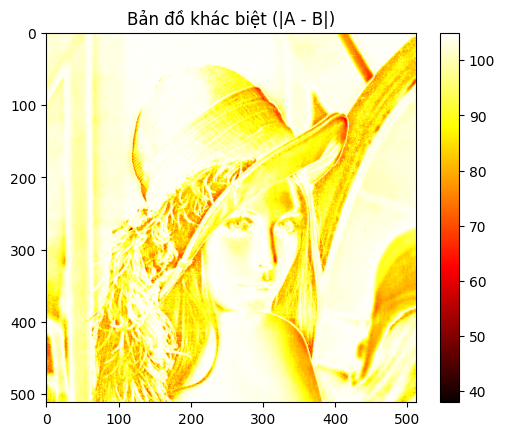

(<matplotlib.image.AxesImage at 0x7d53dfeda990>,
 Text(0.5, 1.0, 'Bản đồ khác biệt (|A - B|)'),
 None)

In [44]:
# chọn 2 thứ tự xử lý
# Thứ tự A: Negative -> Gamma
resA, stagesA = point_processing_pipeline(img, use_negative=True, gamma=0.5)

# Thứ tự B: Gamma -> Negative
def pipeline_gamma_then_negative(gray, gamma):
    result = gamma_transform(gray, gamma)
    stage_gamma = result.copy()
    result = negative(result)
    stage_neg = result.copy()
    return result, {'original': gray.copy(), 'gamma': stage_gamma, 'negative': stage_neg}

resB, stagesB = pipeline_gamma_then_negative(img, gamma=0.5)

show_pipeline_stages(stagesA, "Thứ tự A: Negative -> Gamma(0.5)")
show_pipeline_stages(stagesB, "Thứ tự B: Gamma(0.5) -> Negative")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(resA, cmap="gray"), plt.title("A: Negative rồi Gamma")
plt.subplot(1, 2, 2), plt.imshow(resB, cmap="gray"), plt.title("B: Gamma rồi Negative")
plt.show()

diff = cv2.absdiff(resA, resB)
print("Số pixel khác nhau giữa 2 kết quả:", np.count_nonzero(diff))
print("Mean A:", np.mean(resA), " Mean B:", np.mean(resB))
plt.imshow(diff, cmap="hot"), plt.title("Bản đồ khác biệt (|A - B|)"), plt.colorbar(), plt.show()

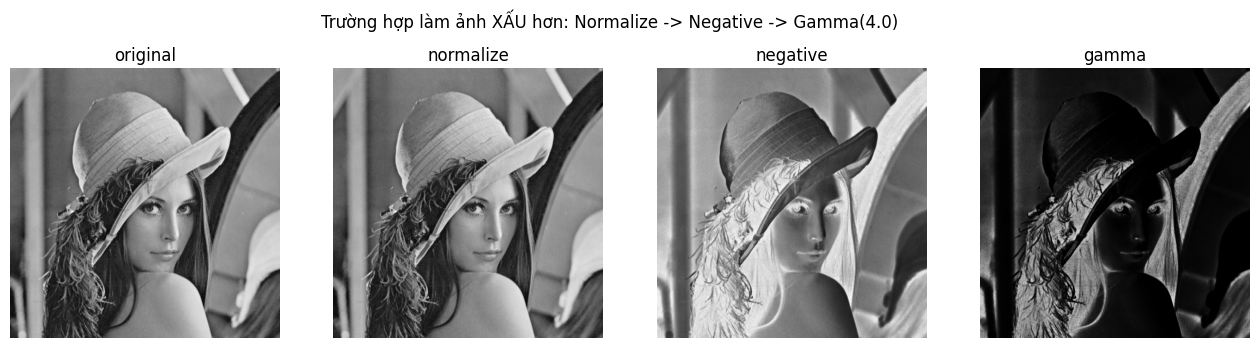

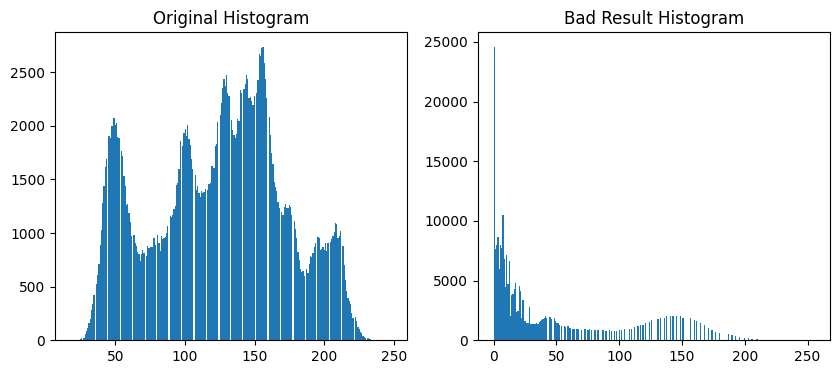

Original - Mean: 124.20059967041016 Std: 47.90295196809465
Bad result - Mean: 42.06129455566406 Std: 50.992070913800234


In [45]:
# làm ảnh xấu hơn
res_bad, stages_bad = point_processing_pipeline(img, normalize=True, use_negative=True, gamma=4.0)

show_pipeline_stages(stages_bad, "Trường hợp làm ảnh XẤU hơn: Normalize -> Negative -> Gamma(4.0)")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.hist(img.ravel(), bins=256), plt.title("Original Histogram")
plt.subplot(1, 2, 2), plt.hist(res_bad.ravel(), bins=256), plt.title("Bad Result Histogram")
plt.show()

print("Original - Mean:", np.mean(img), "Std:", np.std(img))
print("Bad result - Mean:", np.mean(res_bad), "Std:", np.std(res_bad))

# Giải thích:
- phép biến đổi điểm ảnh (point processing) nói chung là các hàm số học áp lên từng pixel; chỉ khi cả hai phép biến đổi cùng thuộc một nhóm đại số đóng dưới phép hợp (ví dụ cả hai đều là hàm tuyến tính dạng ar+b) thì thứ tự mới có thể hoán đổi mà không đổi kết quả cuối.
 - Ngay khi có sự tham gia của hàm phi tuyến (gamma, log) hoặc phép biến đổi không đối xứng (normalize dựa trên min/max của ảnh sau một bước biến đổi trước), thứ tự sẽ ảnh hưởng trực tiếp đến kết quả — vì mỗi bước làm thay đổi phân bố dữ liệu mà bước tiếp theo xử lý.

# 6 - Nâng cao

Gamma tự động ước lượng: 0.914
Mean trước: 119.94  ->  Mean sau: 126.04


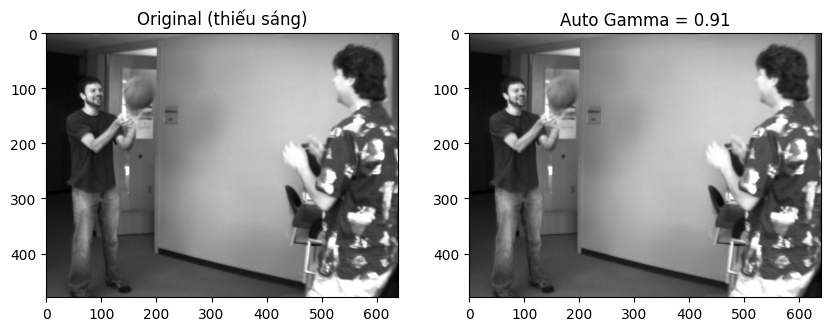

In [46]:
#C1
def auto_gamma(gray, target_mean=128.0):
    mean_in = np.mean(gray.astype(np.float32))
    if mean_in <= 0 or mean_in >= 255:
        return 1.0, gray.copy()

    gamma = np.log(target_mean / 255.0) / np.log(mean_in / 255.0)
    gamma = np.clip(gamma, 0.1, 5.0)

    out = gamma_transform(gray, gamma)
    return gamma, out

gamma_auto, img_auto_gamma = auto_gamma(img_thieusang, target_mean=128)
print(f"Gamma tự động ước lượng: {gamma_auto:.3f}")
print(f"Mean trước: {np.mean(img_thieusang):.2f}  ->  Mean sau: {np.mean(img_auto_gamma):.2f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_thieusang, cmap="gray"), plt.title("Original (thiếu sáng)")
plt.subplot(1, 2, 2), plt.imshow(img_auto_gamma, cmap="gray"), plt.title(f"Auto Gamma = {gamma_auto:.2f}")
plt.show()

r1 (P2%) = 16.0, r2 (P98%) = 249.0


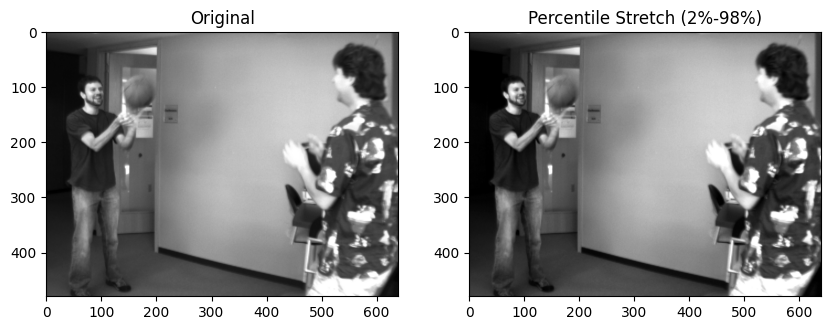

In [47]:
#c2
def percentile_contrast_stretch(gray, low_pct=2, high_pct=98, s1=0, s2=255):
    r1 = np.percentile(gray, low_pct)
    r2 = np.percentile(gray, high_pct)
    if r1 >= r2:
        r1, r2 = np.min(gray), np.max(gray)
    out = piecewise_linear(gray, r1, s1, r2, s2)
    return out, r1, r2

stretched_pct, r1_pct, r2_pct = percentile_contrast_stretch(img_thieusang, 2, 98)
print(f"r1 (P2%) = {r1_pct:.1f}, r2 (P98%) = {r2_pct:.1f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_thieusang, cmap="gray"), plt.title("Original")
plt.subplot(1, 2, 2), plt.imshow(stretched_pct, cmap="gray"), plt.title("Percentile Stretch (2%-98%)")
plt.show()

Kích thước ảnh test: (100, 100)
Thời gian vòng lặp pixel : 0.0566 giây
Thời gian NumPy vectorize: 0.000673 giây
NumPy nhanh hơn khoảng: 84.1 lần
Số pixel khác nhau (do làm tròn): 0


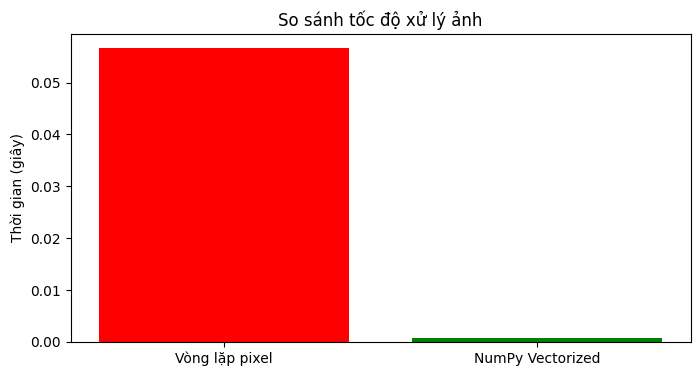

In [48]:
#c3
import time
def gamma_loop(gray, gamma):
    h, w = gray.shape
    out = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            r = gray[i, j] / 255.0
            s = (r ** gamma) * 255.0
            out[i, j] = min(255, max(0, int(s)))
    return out

def gamma_vectorized(gray, gamma):
    r = gray.astype(np.float32) / 255.0
    s = np.power(r, gamma)
    out = np.clip(s * 255.0, 0, 255).astype(np.uint8)
    return out
small_img = cv2.resize(img, (100, 100))

t0 = time.time()
out_loop = gamma_loop(small_img, 0.5)
t_loop = time.time() - t0

t0 = time.time()
out_vec = gamma_vectorized(small_img, 0.5)
t_vec = time.time() - t0

print(f"Kích thước ảnh test: {small_img.shape}")
print(f"Thời gian vòng lặp pixel : {t_loop:.4f} giây")
print(f"Thời gian NumPy vectorize: {t_vec:.6f} giây")
print(f"NumPy nhanh hơn khoảng: {t_loop / t_vec:.1f} lần")

diff = cv2.absdiff(out_loop, out_vec)
print("Số pixel khác nhau (do làm tròn):", np.count_nonzero(diff))

plt.figure(figsize=(8, 4))
plt.bar(["Vòng lặp pixel", "NumPy Vectorized"], [t_loop, t_vec], color=["red", "green"])
plt.ylabel("Thời gian (giây)")
plt.title("So sánh tốc độ xử lý ảnh")
plt.show()

In [49]:
#c4
import ipywidgets as widgets
from IPython.display import display, clear_output

def interactive_gamma(gray):
    out_widget = widgets.Output()

    gamma_slider = widgets.FloatSlider(value=1.0, min=0.1, max=3.0, step=0.05,
                                         description="Gamma:", continuous_update=False)

    def update(change=None):
        with out_widget:
            clear_output(wait=True)
            g = gamma_slider.value
            result = gamma_transform(gray, g)
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1), plt.imshow(gray, cmap="gray"), plt.title("Original")
            plt.subplot(1, 2, 2), plt.imshow(result, cmap="gray"), plt.title(f"Gamma = {g:.2f}")
            plt.show()
            print(f"Mean: {np.mean(result):.2f}, Std: {np.std(result):.2f}")

    gamma_slider.observe(update, names="value")
    display(gamma_slider, out_widget)
    update()

def interactive_piecewise(gray):
    out_widget = widgets.Output()

    r1_slider = widgets.IntSlider(value=60, min=0, max=254, description="r1:", continuous_update=False)
    s1_slider = widgets.IntSlider(value=20, min=0, max=255, description="s1:", continuous_update=False)
    r2_slider = widgets.IntSlider(value=180, min=1, max=255, description="r2:", continuous_update=False)
    s2_slider = widgets.IntSlider(value=235, min=0, max=255, description="s2:", continuous_update=False)

    def update(change=None):
        with out_widget:
            clear_output(wait=True)
            r1, s1, r2, s2 = r1_slider.value, s1_slider.value, r2_slider.value, s2_slider.value
            if r1 >= r2:
                print("r1 phải nhỏ hơn r2!")
                return
            result = piecewise_linear(gray, r1, s1, r2, s2)

            x = np.arange(0, 256)
            y = piecewise_linear(np.array([x]), r1, s1, r2, s2)[0]

            fig, axes = plt.subplots(1, 3, figsize=(15, 4))
            axes[0].plot(x, y), axes[0].set_title("Transfer Function")
            axes[1].imshow(gray, cmap="gray"), axes[1].set_title("Original"), axes[1].axis("off")
            axes[2].imshow(result, cmap="gray"), axes[2].set_title("Stretched"), axes[2].axis("off")
            plt.show()

    for s in [r1_slider, s1_slider, r2_slider, s2_slider]:
        s.observe(update, names="value")
    display(widgets.VBox([r1_slider, s1_slider, r2_slider, s2_slider]), out_widget)
    update()


print("Interactive Gamma")
interactive_gamma(img)

print("Interactive Piecewise Linear")
interactive_piecewise(img)

=== Interactive Gamma ===


FloatSlider(value=1.0, continuous_update=False, description='Gamma:', max=3.0, min=0.1, step=0.05)

Output()

=== Interactive Piecewise Linear ===


Output()

## 7. Câu hỏi phân tích bắt buộc
1. **dtype:** uint8 dễ bị quấn vòng (tràn số) khi tính toán, dùng float32 để giữ độ chính xác thập phân và miền giá trị lớn trước khi chuyển lại.
2. **Chuyển float32 cho log/gamma:** Các hàm này yêu cầu dữ liệu chính xác dạng float và khoảng [0, 1] để không bị thất thoát thông tin do làm tròn quá sớm.
3. **Clip trước khi cast uint8:** Ép kiểu uint8 sẽ quấn vòng giá trị (VD: 256 thành 0), làm sai hoàn toàn cường độ điểm ảnh, nên phải clip [0, 255] trước.
4. **Negative histogram:** Lật ngược đối xứng histogram của ảnh gốc qua trục giữa cường độ.
5. **Log transform:** Mở rộng và kéo giãn vùng mức xám thấp (vùng tối) để lộ chi tiết.
6. **Gamma:** Gamma < 1 làm sáng ảnh (kéo dãn tối), Gamma > 1 làm tối ảnh (nén tối, giãn sáng).
7. **Piecewise so với Gamma:** Piecewise linh hoạt cho phép thiết lập độ dốc khác nhau ở nhiều đoạn vùng sáng/tối tùy ý, trong khi Gamma chỉ là 1 đường cong cố định.
8. **Histogram:** Mắt người kém nhạy bén với một số mức độ tương phản và bị đánh lừa bởi môi trường, histogram cung cấp phân bố cường độ chính xác, khách quan.
9. **Thứ tự giao hoán:** Các phép phi tuyến không giao hoán. Ví dụ Negative rồi Gamma(0.5) khác hoàn toàn với Gamma(0.5) rồi Negative vì miền phân bố dữ liệu đã bị biến đổi khác biệt ở mỗi bước.
